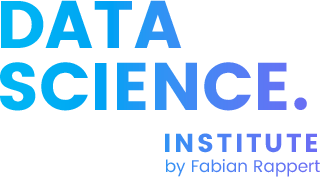

# Namensräume (Namespaces)

Um zu verstehen, wie Python den Zugriff auf Variablen handhabt und was passiert, wenn in verschiedenen Funktionen gleichnamige Variablen verwendet werden, ist es hilfreich, das Konzept von **Namensräumen** (Namespaces) zu betrachten. 

In diesem Tutorial schauen wir uns auf den **eingebauten Namensraum**, den **globalen Namensraum** und den **lokalen Namensraum** genauer an.


Betrachten wir als Beispiel das Verhalten des folgenden Programms:

In [ ]:
x = 10


def print_local_x():
    local_x = 5
    print("Der Wert von x innerhalb der Funktion lautet", local_x)


print_local_x()
print("Der Wert von x außerhalb der Funktion lautet", x)

In diesem Programm wurde die Variable `x` zweimal definiert: einmal innerhalb der Funktion `print_local_x` und einmal außerhalb. <br>
Wie entscheidet Python, auf welches `x` zugegriffen wird?

Der Zugriff auf Variablen und die Sichtbarkeit von Funktionen in Python werden durch **Namensräume (Namespaces)** bestimmt.

Ein **Namensraum** ist ein Bereich innerhalb eines Programms, in dem ein Name (z.B. einer Funktion oder Variable) gültig und ansprechbar ist.

Namensräume helfen dabei, Konflikte zu vermeiden, die auftreten können, wenn verschiedene Module dieselben Namen für Variablen verwenden.


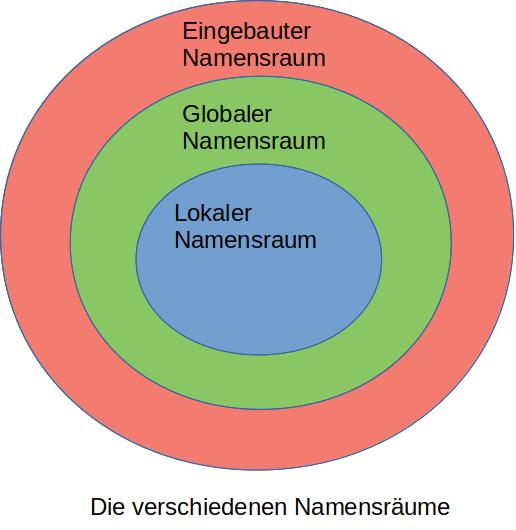

Python unterscheidet zwischen drei Arten von Namensräumen:
    
- Der **eingebaute Namensraum (built-in namespace)** enthält alle eingebauten Objekte in Python und ist überall im Programm verfügbar. Hier findest du python-eigene Namen wie `print` und `abs`, die bereits definiert sind, bevor jeglicher eigener Code ausgeführt wird.
- Der **globale Namensraum (global namespace)** bezieht sich auf die Objekte bzw. Variablen, die auf der obersten Ebene eines Skripts definiert sind, und ist innerhalb einer Datei überall zugänglich.
- Der **lokale Namensraum (local namespace)** umfasst Namen, die innerhalb einer Funktion definiert sind und nur in diesem lokalen Kontext verfügbar sind. Jede Funktion hat also ihren eigenen Namensraum.

Der eingebaute Namensraum umfasst den globalen Namensraum, der wiederum den lokalen Namensraum einschließt. Dabei ist der Zugriff von äußeren auf innere Namensräume nicht möglich; beispielsweise können Variablen aus lokalen Namensräumen nicht im globalen Namensraum angesprochen werden.


In [ ]:
# Globaler Namensraum
y = 0


def set_local_y_in_first_function():
    # Lokaler Namensraum der ersten Funktion
    local_y = 5


def set_local_y_in_second_function():
    # Lokaler Namensraum der zweiten Funktion
    local_y = 10

Im folgenden wollen wir näher auf die einzelnen Namensräume eingehen.

***

## Der eingebaute Namensraum

Sämtliche Namen des eingebauten Namensraums - also die Funktionen, die uns Python zur Verfügung stellt - können über den Befehl `dir(__builtins__)` 
aufgelistet werden. 

In [ ]:
dir(__builtins__)

Wir sehen, dass wir eine recht große Auswahl an Befehlen haben. So finden wir z.B. den uns bekannten Befehl `print` in der Liste. Tatsächlich können wir uns auch die Art dieser Funktion über `type` ausgeben lassen.

In [ ]:
type(print)

Wir werden aufgeklärt, dass der Name `print` eine eingebaute (*built-in*) Funktion in Python ist. Dies gilt natürlich auch für die anderen Funktionen, die sich im eingebauten Namensraum befinden.

***
## Der globale Namensraum

Der globale Namensraum umfasst alle Namen, die auf der Ebene des Hauptprogramms definiert werden.
Um die Elemente des globalen Namensraums zu jeder Zeit anzeigen zu lassen, verwendet man den Befehl `globals()`. Das Ergebnis ist ein Wörterbuch, das alle Namen im globalen Namensraum enthält.


In [ ]:
globals()

Es ist oft praktischer, direkt zu überprüfen, ob ein bestimmter Name im Wörterbuch existiert. Im folgenden Beispiel wird eine Variable `my_number` im globalen Namensraum definiert. Vor und nach dieser Definition überprüfen wir, ob der Name `my_number` im globalen Namensraum vorhanden ist:

In [ ]:
print("my_number" in globals())
my_number = 3
print("my_number" in globals())

> <span style="color:red"> **_WICHTIG:_** </span> Da wir in Jupyter Notebook einzelne Zellen ausführen können, ist die Ausgabe der obigen Zelle beim zweiten Mal anders (verifizier dies!). Das liegt daran, dass die Variable beim ersten Ausführen der Zelle definiert wird und dann im Speicher bleibt. Damit der globale Namensraum wieder "auf Null" gesetzt wird, müssen wir den Kernel neu starten (obige Leiste). Dadurch werden alle Definitionen gelöscht und das Programm startet quasi von neuem.

***
## Der lokale Namensraum

Der **lokale Namensraum** wird erzeugt wenn eine Funktion aufgerufen wird und existiert bis zu dem Zeitpunkt an dem die Funktion wieder verlassen wird.

Im folgenden Beispiel wird eine Funktion `namespace` erzeugt und dadurch eben auch den lokale Namensraum.

In [ ]:
# Hauptprogramm
# Alles hier definierte, ist im globalen Namensraum
global_var = "Globale Variable"


def namespace_demo():
    # Lokaler Namensraum der Funktion namespace_demo beginnt hier
    local_var1 = "Lokale Variable"  # local_var1 wird lokal definiert und ändert global_var NICHT.
    local_var2 = "Lokale Variable"  # Der Name local_var2 ist nun im lokalen Namensraum

    print("Der Wert der LOKALEN Variable local_var1 ist:", local_var1)
    print("Der Wert der LOKALEN Variable local_var2 ist:", local_var2)
    # Lokaler Namensraum der Funktion namespace_demo endet hier.


namespace_demo()

print("Der Wert der GLOBALEN Variable global_var ist:", global_var)

# Der Zugriff auf local_var2 hier würde zu einem Fehler führen, da local_var2 nicht im globalen Namensraum definiert ist.
# Daher ist die folgende Zeile auskommentiert, um den Fehler zu vermeiden.
# print("Der Wert der GLOBALEN Variable local_var2 ist:", local_var2)

Aus diesem Beispiel wird deutlich, dass die lokale und globale Variable `global_var` bzw. `local_var1` unabhängig voneinander sind und ihre jeweiligen Werte beibehalten.

Ein Versuch, im globalen Namensraum auf die lokale Variable `local_var2` zuzugreifen, führt zu einem `NameError`, da `local_var2` außerhalb ihres lokalen Namensraums nicht bekannt ist.


Ähnlich wie beim globalen Namensraum können wir mit dem Befehl `locals()` auf die Namen im lokalen Namensraum zugreifen. Dieser Befehl liefert ein Wörterbuch, das die Variablen des lokalen Namensraums enthält. 

Wichtig ist, dass `locals()` innerhalb des entsprechenden lokalen Namensraums aufgerufen werden muss, um die lokalen Variablen anzuzeigen.


Eine Funktion `local_namespace` wird definiert, die zwei lokale Variablen enthält: die Variable `local_var1` und das Wörterbuch `local_var2`. Anschließend wird der lokale Namensraum ausgegeben. Dort finden wir, wie erwartet, unsere Variablen.


In [ ]:
def local_namespace():
    local_var1 = 5
    local_var2 = {"A": 3}

    print("Verfügbare lokale Variablen:")
    print(locals())


local_namespace()

Ein Argument, welches wir einer Funktion übergeben, befindet sich auch im lokalen Namensraum:

In [ ]:
def local_print(number):
    print("Lokaler Namensraum der Funktion local_print:", locals())


local_print(3)

Wir betrachten erneut die Unterschiede von lokalem und globalen Namensraum in einem Beispiel:

In [ ]:
def display_namespaces(funktionsname):
    # Zeigt den lokalen Namensraum der aktuell aufgerufenen Funktion
    print(f"Lokaler Namensraum in '{funktionsname}':", locals())
    # Zeigt den globalen Namensraum
    print("Globaler Namensraum:", globals())


def funktion_eins():
    x = 5
    z = 4
    # Zeigt die Namensräume innerhalb der funktion_eins
    display_namespaces("funktion_eins")


def funktion_zwei():
    x = 15
    z = 14
    m = 3
    # Zeigt die Namensräume innerhalb der funktion_zwei
    display_namespaces("funktion_zwei")


# Ruft jede Funktion auf, um die Sichtbarkeit des lokalen Namensraums zu demonstrieren
funktion_eins()
funktion_zwei()

Wir sehen (obwohl er sehr groß ist), dass der globale Namensraum in beiden Funktionen **exakt** der selbe ist. <br>
Die lokalen Namensräume unterscheiden sich dahingegen.

***
## Globale Variablen in Funktionen ändern

Es ist durchaus möglich, globale Variablen innerhalb von Funktionen zu ändern. Obwohl unsere vorherigen Beispiele hauptsächlich gezeigt haben, wie innerhalb einer Funktion *lokale* Variablen erzeugt und modifiziert werden, bietet Python die Flexibilität, auch auf globale Variablen zuzugreifen und diese zu ändern.

Um auf eine globale Variable innerhalb einer Funktion zuzugreifen und sie zu ändern, nutzen wir das Schlüsselwort `global`:


In [ ]:
var = "Globale Variable"


def funktion_drei():
    print("Wert von x:", var)


funktion_drei()

Trotz des Zugriffs auf `global_var` innerhalb von `funktion_drei` und des scheinbaren Versuchs, ihren Wert zu ändern, bleibt die globale Variable unverändert. 

Dies liegt daran, dass Python standardmäßig annimmt, dass Variablen, die innerhalb einer Funktion zugewiesen werden, lokal für diese Funktion sind, es sei denn, es wird explizit anders angegeben.


In [ ]:
def funktion_vier():
    var = "Lokale Variable"
    print("Der Wert der Variablen var (innerhalb der Funktion):", var)


funktion_vier()

print("Der Wert der Variablen var (global):", var)

Um auf die globale Variable `var` zuzugreifen, müssen wir das Schlüsselwort `global` vor dem Variablennamen verwenden. Dies signalisiert Python, dass die globale Variable `var` (und nicht die lokale) gemeint ist.

In [ ]:
def funktion_fuenf():
    global var  # Der Name var1 referenziert jetzt die globale Variable var1!
    var = "Lokale Variable"
    print("Der Wert der Variablen var (innerhalb der Funktion):", var)


funktion_fuenf()

print("Der Wert der Variablen var (global):", var)

Der Wert der globalen Variablen wurde nun in der Funktion geändert

In [ ]:
locals() == globals()  # True